In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
!pip install yfinance

In [7]:
stock = "AAPL"

# Download stock data

df = yf.download(stock, start="2023-01-01", end="2025-01-01")

# Show first 5 rows


[*********************100%***********************]  1 of 1 completed


TypeError: 'DataFrame' object is not callable

In [8]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2023-01-03,122.982727,128.715425,122.097746,128.105777,112117500
2023-01-04,124.251198,126.512816,122.992561,124.772352,89113600
2023-01-05,122.933548,125.637653,122.677892,125.008335,80962700
2023-01-06,127.456787,128.115604,122.805730,123.907041,87754700
2023-01-09,127.977951,131.183555,127.722296,128.292618,70790800
...,...,...,...,...,...
2024-12-24,256.560791,256.570707,253.669247,253.867989,23234700
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100
2024-12-27,253.967377,257.057649,251.453440,256.193146,42355300


In [6]:
print(df.shape)
print(df.columns)
print(df.info())

(502, 5)
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2023-01-03 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   502 non-null    float64
 1   (High, AAPL)    502 non-null    float64
 2   (Low, AAPL)     502 non-null    float64
 3   (Open, AAPL)    502 non-null    float64
 4   (Volume, AAPL)  502 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB
None


In [9]:
print(df.isnull().sum())

# Drop missing values

df.dropna(inplace=True)

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


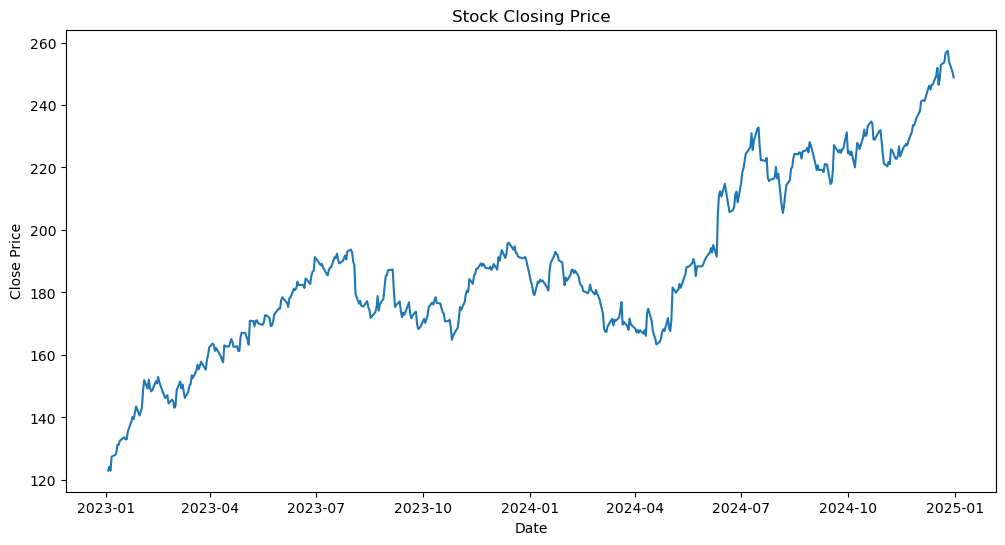

In [10]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title('Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.show()

In [11]:
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

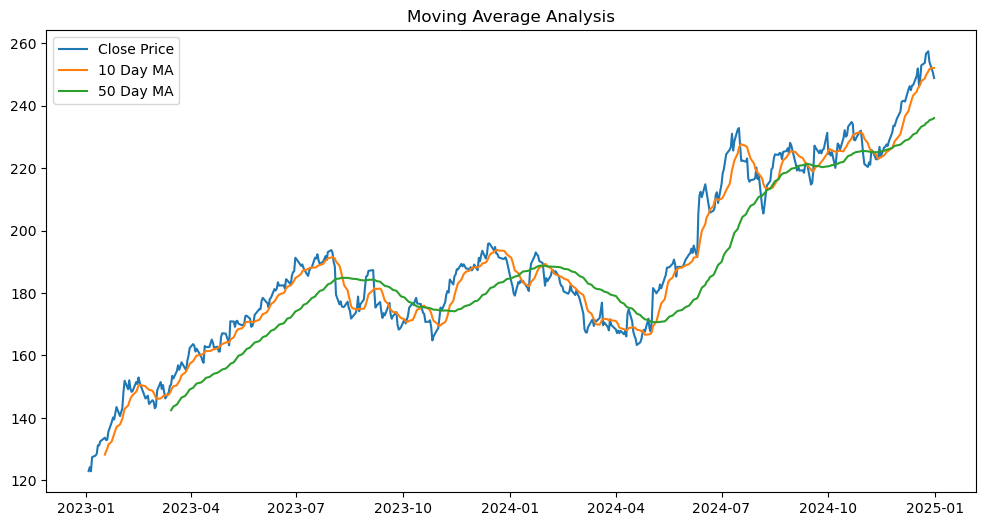

In [12]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_10'], label='10 Day MA')
plt.plot(df['MA_50'], label='50 Day MA')

plt.legend()
plt.title('Moving Average Analysis')

plt.show()

In [13]:
df['Prediction'] = df['Close'].shift(-1)

In [14]:
X = np.array(df[['Close']])
X = X[:-1]

y = np.array(df['Prediction'])
y = y[:-1]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred = model.predict(X_test)

In [18]:
y_pred

array([211.42883823, 165.44665955, 218.54012365, 174.69157231,
       178.7604497 , 220.32782967, 225.99710237, 190.06862286,
       158.05892286, 233.35726386, 134.15213622, 177.86918091,
       224.50734229, 163.64142641, 241.37381849, 220.87834559,
       253.67839278, 153.37902829, 167.13329197, 224.96218108,
       249.49108188, 251.90646574, 182.61880396, 192.93948396,
       163.19006872, 220.51248014, 257.39052552, 174.77026956,
       175.17451835, 171.65071481, 214.55977877, 180.21217607,
       225.24892364, 174.42594439, 123.45481303, 167.97166015,
       224.85341561, 163.07236488, 172.13372165, 163.48442714,
       224.82375783, 170.64537529, 245.24436421, 168.90692156,
       146.65850808, 161.65955389, 123.5038069 , 133.49577348,
       228.20552021, 152.33369409, 164.30856688, 174.20950795,
       188.18229065, 223.00432665, 176.48204497, 156.91104054,
       176.6973109 , 141.06817585, 169.31027348, 161.64974904,
       252.90627197, 189.68679602, 166.68944374, 241.57

In [26]:
y_test

array([212.40008545, 164.11901855, 219.64732361, 171.82608032,
       177.09724426, 216.48472595, 226.71607971, 188.68482971,
       163.04556274, 234.72045898, 132.95349121, 178.45228577,
       224.20925903, 170.93391418, 245.1835022 , 219.17698669,
       256.56079102, 151.37548828, 167.98501587, 224.71546936,
       251.87078857, 246.47525024, 182.03410339, 194.18785095,
       161.28271484, 221.78741455, 253.96737671, 176.99075317,
       174.79948425, 181.55883789, 215.91145325, 180.58859253,
       220.04052734, 172.03346252, 127.45678711, 171.31164551,
       222.85939026, 162.7205658 , 175.35150146, 161.27287292,
       225.82714844, 172.62986755, 246.19703674, 169.07096863,
       146.6484375 , 161.27287292, 124.25119781, 135.5690918 ,
       227.29612732, 149.19781494, 165.08413696, 169.81159973,
       188.05363464, 225.15219116, 177.55361938, 157.81619263,
       177.31419373, 141.88195801, 164.80496216, 165.8522644 ,
       253.64941406, 191.71984863, 165.38111877, 241.29

In [19]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 7.219532600891849
R2 Score: 0.9934273226625111


In [20]:
future_price = model.predict([[180]])

print("Predicted Future Price:", future_price)

Predicted Future Price: [180.30634827]


In [21]:
current_price = 180
predicted_price = future_price[0]

if predicted_price > current_price:
    print("BUY SIGNAL")
else:
    print("SELL SIGNAL")

BUY SIGNAL


In [22]:
returns = df['Close'].pct_change()

risk = returns.std()

print("Risk (Standard Deviation):", risk)

Risk (Standard Deviation): Ticker
AAPL    0.013452
dtype: float64


<Figure size 1200x600 with 0 Axes>

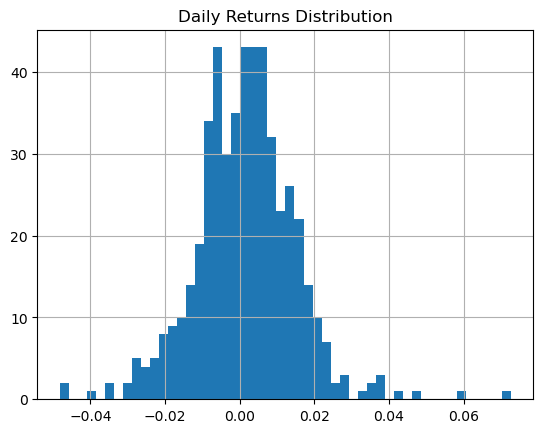

In [23]:
plt.figure(figsize=(12,6))

returns.hist(bins=50)

plt.title('Daily Returns Distribution')
plt.show()

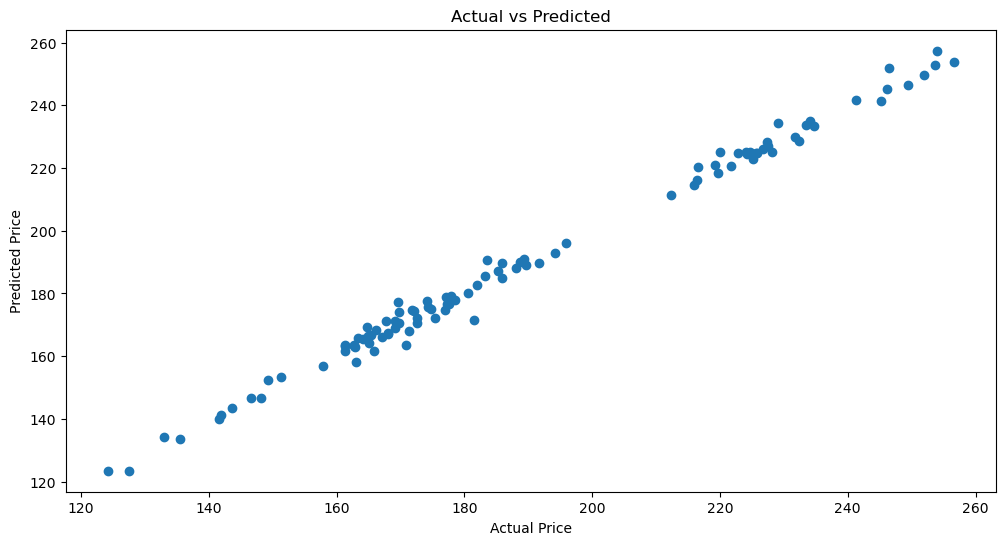

In [24]:
plt.figure(figsize=(12,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()

In [25]:
df.to_csv('stock_data.csv')